<a href="https://colab.research.google.com/github/Dovila-hub/Dovila-hub/blob/main/02_train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!git clone https://github.com/luna-eng-data/wildlife-conflict-detection.git
%cd wildlife-conflict-detection

fatal: destination path 'wildlife-conflict-detection' already exists and is not an empty directory.
/content/wildlife-conflict-detection


# Entraînement du modèle YOLO
## Projet : Détection de conflits homme-faune

**Équipe DIA6 - Novembre 2025**

---

### Instructions d'utilisation

1. **Activer le GPU** : Runtime > Change runtime type > T4 GPU
2. **Exécuter les cellules dans l'ordre** (Shift + Enter)
3. **Durée totale** : ~2 heures (dont 1h30 d'entraînement automatique)
4. **Points de vérification** : Après chaque section, vérifier que tout est OK

---

### Prérequis

- Dataset uploadé sur Google Drive dans : `MyDrive/ProjetGreenAI/datasets/wildlife_human_final/`
- Connexion internet stable
- Compte Google

---

## Section 1 : Vérification de l'environnement

**Objectif** : Vérifier que le GPU est activé et que l'environnement est correct

**Résultat attendu** : Vous devez voir "GPU : Tesla T4" ou similaire

In [19]:
import sys
import torch

print("Environment settings")
print("-" * 50)
print(f"Python version : {sys.version}")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print("\n GPU detected ")
else:
    print("\n GPU not detected !")
    print("Go to Runtime > Change runtime type > choose GPU")

print("-" * 50)

Environment settings
--------------------------------------------------
Python version : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch version : 2.9.0+cu126
CUDA disponible : True
GPU : Tesla T4

 GPU detected 
--------------------------------------------------


In [20]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.7 MB/s eta 0:00:00


## Section 2 : Installation des dépendances

**Objectif** : Installer Ultralytics (librairie YOLO)

**Durée** : 1-2 minutes

**Note** : Des messages d'avertissement peuvent apparaître, c'est normal

In [21]:

import ultralytics
print(f"Ultralytics version : {ultralytics.__version__}")
ultralytics.checks()

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.1/112.6 GB disk)


## Section 3 : Connexion à Google Drive

**Objectif** : Monter Google Drive pour accéder au dataset

**Action requise** :
1. Une fenêtre va s'ouvrir
2. Cliquez sur "Connect to Google Drive"
3. Sélectionnez votre compte Google
4. Cliquez sur "Allow"

**Résultat attendu** : "Drive monte avec succes" + "Dataset trouve"

In [25]:
from google.colab import drive
import os

print("Connect to  Google Drive...")
drive.mount('/content/drive')
print("\n drive mount sucessful")

# Verifier l'acces au dataset
DATASET_PATH = '/content/drive/MyDrive/GREEN_AI_PROJECT/wildlife_human_final'

print(f"\n Searching for the dataset...")
if os.path.exists(DATASET_PATH):
    print(f" Dataset found")
    print(f" Path : {DATASET_PATH}")
else:
    print(f" Error : Dataset not found")
    print(f" Expected file path : {DATASET_PATH}")
    print("\n Restart the process:")

Connect to  Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 drive mount sucessful

 Searching for the dataset...
 Dataset found
 Path : /content/drive/MyDrive/GREEN_AI_PROJECT/wildlife_human_final


## Section 4 : Vérification de la structure du dataset

**Objectif** : Vérifier que toutes les images et labels sont présents

**Résultat attendu** :
- train  : 1650 images, 1650 labels
- valid  :  205 images,  205 labels
- test   :  208 images,  208 labels

**Si vous voyez "DOSSIER MANQUANT", arrêtez-vous et vérifiez votre Google Drive**

In [26]:
from pathlib import Path

print("\n Dataset structure ")
print("-" * 50)

all_ok = True

for split in ['train', 'valid', 'test']:
    images_dir = Path(DATASET_PATH) / split / 'images'
    labels_dir = Path(DATASET_PATH) / split / 'labels'

    if images_dir.exists() and labels_dir.exists():
        n_images = len(list(images_dir.glob('*')))
        n_labels = len(list(labels_dir.glob('*.txt')))
        print(f" {split:6s} : {n_images:4d} images, {n_labels:4d} labels")
    else:
        print(f" {split:6s} : Missing File")
        all_ok = False
        if not images_dir.exists():
            print(f"   Missing : {images_dir}")
        if not labels_dir.exists():
            print(f"   Missing : {labels_dir}")

print("-" * 50)

if all_ok:
    print("\n Correct Data structure")
else:
    print("\n Incorrect (try again)")


 Dataset structure 
--------------------------------------------------
 train  : 1650 images, 1615 labels
 valid  :  205 images,  201 labels
 test   :  208 images,  207 labels
--------------------------------------------------

 Correct Data structure


## Section 5 : Vérification du fichier data.yaml

**Objectif** : Vérifier que le fichier de configuration existe et est correct

**Contenu attendu** :
- path: chemin vers le dataset
- train, val, test: chemins relatifs
- names: liste des 5 classes

In [27]:
YAML_PATH = Path(DATASET_PATH) / 'data.yaml'

if YAML_PATH.exists():
    print("\n  data.yaml file found")
    print("\n file content  :")
    print("-" * 50)
    with open(YAML_PATH, 'r') as f:
        content = f.read()
        print(content)
    print("-" * 50)
else:
    print("\n ERROR:  data.yaml not found ")
    print(f" Expected file path : {YAML_PATH}")
    print("\n File creation...")

    yaml_content = f"""path: {DATASET_PATH}
train: train/images
val: valid/images
test: test/images

names:
  0: buffalo
  1: elephant
  2: rhinoceros
  3: zebra
  4: person

nc: 5
"""

    with open(YAML_PATH, 'w') as f:
        f.write(yaml_content)

    print(" data.yaml created ")


  data.yaml file found

 file content  :
--------------------------------------------------
path: /content/drive/MyDrive/GREEN_AI_PROJECT/wildlife_human_final
train: train/images
val: valid/images
test: test/images

names:
  0: buffalo
  1: elephant
  2: rhino
  3: zebra
  4: person

--------------------------------------------------


## Section 6 : Chargement du modèle YOLO

**Objectif** : Charger le modèle YOLOv8 nano pré-entraîné

**Note** : Le modèle (6 MB) se télécharge automatiquement

In [28]:
from ultralytics import YOLO

print("\n Loading the YOLOv8 nano model ...")
model = YOLO("yolov8n.pt")
print(" Model loaded sucessfully ")
print(f"Size of the model : ~6 MB")
print(f"Architecture : YOLOv8 nano")
print(f" Pre-trained on : COCO dataset (80 classes)")


 Loading the YOLOv8 nano model ...
 Model loaded sucessfully 
Size of the model : ~6 MB
Architecture : YOLOv8 nano
 Pre-trained on : COCO dataset (80 classes)


---
##  Section 7 : ENTRAÎNEMENT DU MODÈLE

**CETTE CELLULE PREND 40 - 50 minutes**

### Paramètres d'entraînement
- **Époques** : 50 (nombre de fois que le modèle voit toutes les images)
- **Batch size** : 16 (nombre d'images traitées simultanément)
- **Image size** : 640x640 pixels
- **Patience** : 10 (arrêt automatique si pas d'amélioration pendant 10 époques)

### Pendant l'entraînement
- Vous verrez défiler les époques (Epoch 1/50, 2/50, etc.)
- Des métriques s'afficheront (mAP, precision, recall)
- **NE FERMEZ PAS LE NAVIGATEUR**
- Vous pouvez minimiser l'onglet et faire autre chose

### Après l'entraînement
- Le meilleur modèle est sauvegardé automatiquement
- Des graphiques sont générés automatiquement

---

In [29]:
print("\n" + "="*50)
print("DEMARRAGE DE L'ENTRAINEMENT")
print("="*50)
print("="*50 + "\n")

# Parametres
EPOCHS = 50
BATCH_SIZE = 16
IMAGE_SIZE = 640

# Entrainement
results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=10,
    device= '0',
    project='runs/detect',
    name='wildlife_conflict',
    exist_ok=True,
    verbose=True,
    plots=True,
    save=True
)

print("\n" + "="*50)
print("Model trained sucessfully")
print("="*50)


DEMARRAGE DE L'ENTRAINEMENT

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GREEN_AI_PROJECT/wildlife_human_final/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=wildlife_conflict, nbs=64, nms=False, opset=None, optimize=False, opti

## Section 8 : Résultats de l'entraînement

**Objectif** : Afficher les métriques de performance du modèle

**Métriques importantes** :
- **mAP50** : Précision moyenne à 50% de seuil (>0.85 = très bon)
- **Precision** : % de détections correctes
- **Recall** : % d'objets trouvés

In [30]:
print("\n Model results")
print("-" * 50)

# Metrics
metrics = model.metrics

print(f"mAP50     : {metrics.box.map50:.3f}")
print(f"mAP50-95  : {metrics.box.map:.3f}")
print(f"Precision : {metrics.box.mp:.3f}")
print(f"Recall    : {metrics.box.mr:.3f}")

print("-" * 50)

# Interpretation
if metrics.box.map50 > 0.85:
    print("\n Best Model")
elif metrics.box.map50 > 0.75:
    print("\n Good Model")
elif metrics.box.map50 > 0.65:
    print("\n Fair ( could do better ) ")
else:
    print("\n Bad (try more training)")


 Model results
--------------------------------------------------
mAP50     : 0.963
mAP50-95  : 0.829
Precision : 0.960
Recall    : 0.891
--------------------------------------------------

 Best Model


## Section 9 : Visualisation des résultats

**Objectif** : Afficher les courbes d'entraînement et la matrice de confusion

**Graphiques générés** :
- Courbes d'entraînement (loss, mAP, etc.)
- Matrice de confusion (quelles classes sont confondues)
- Exemples de prédictions


 Courbes d'entrainement
--------------------------------------------------


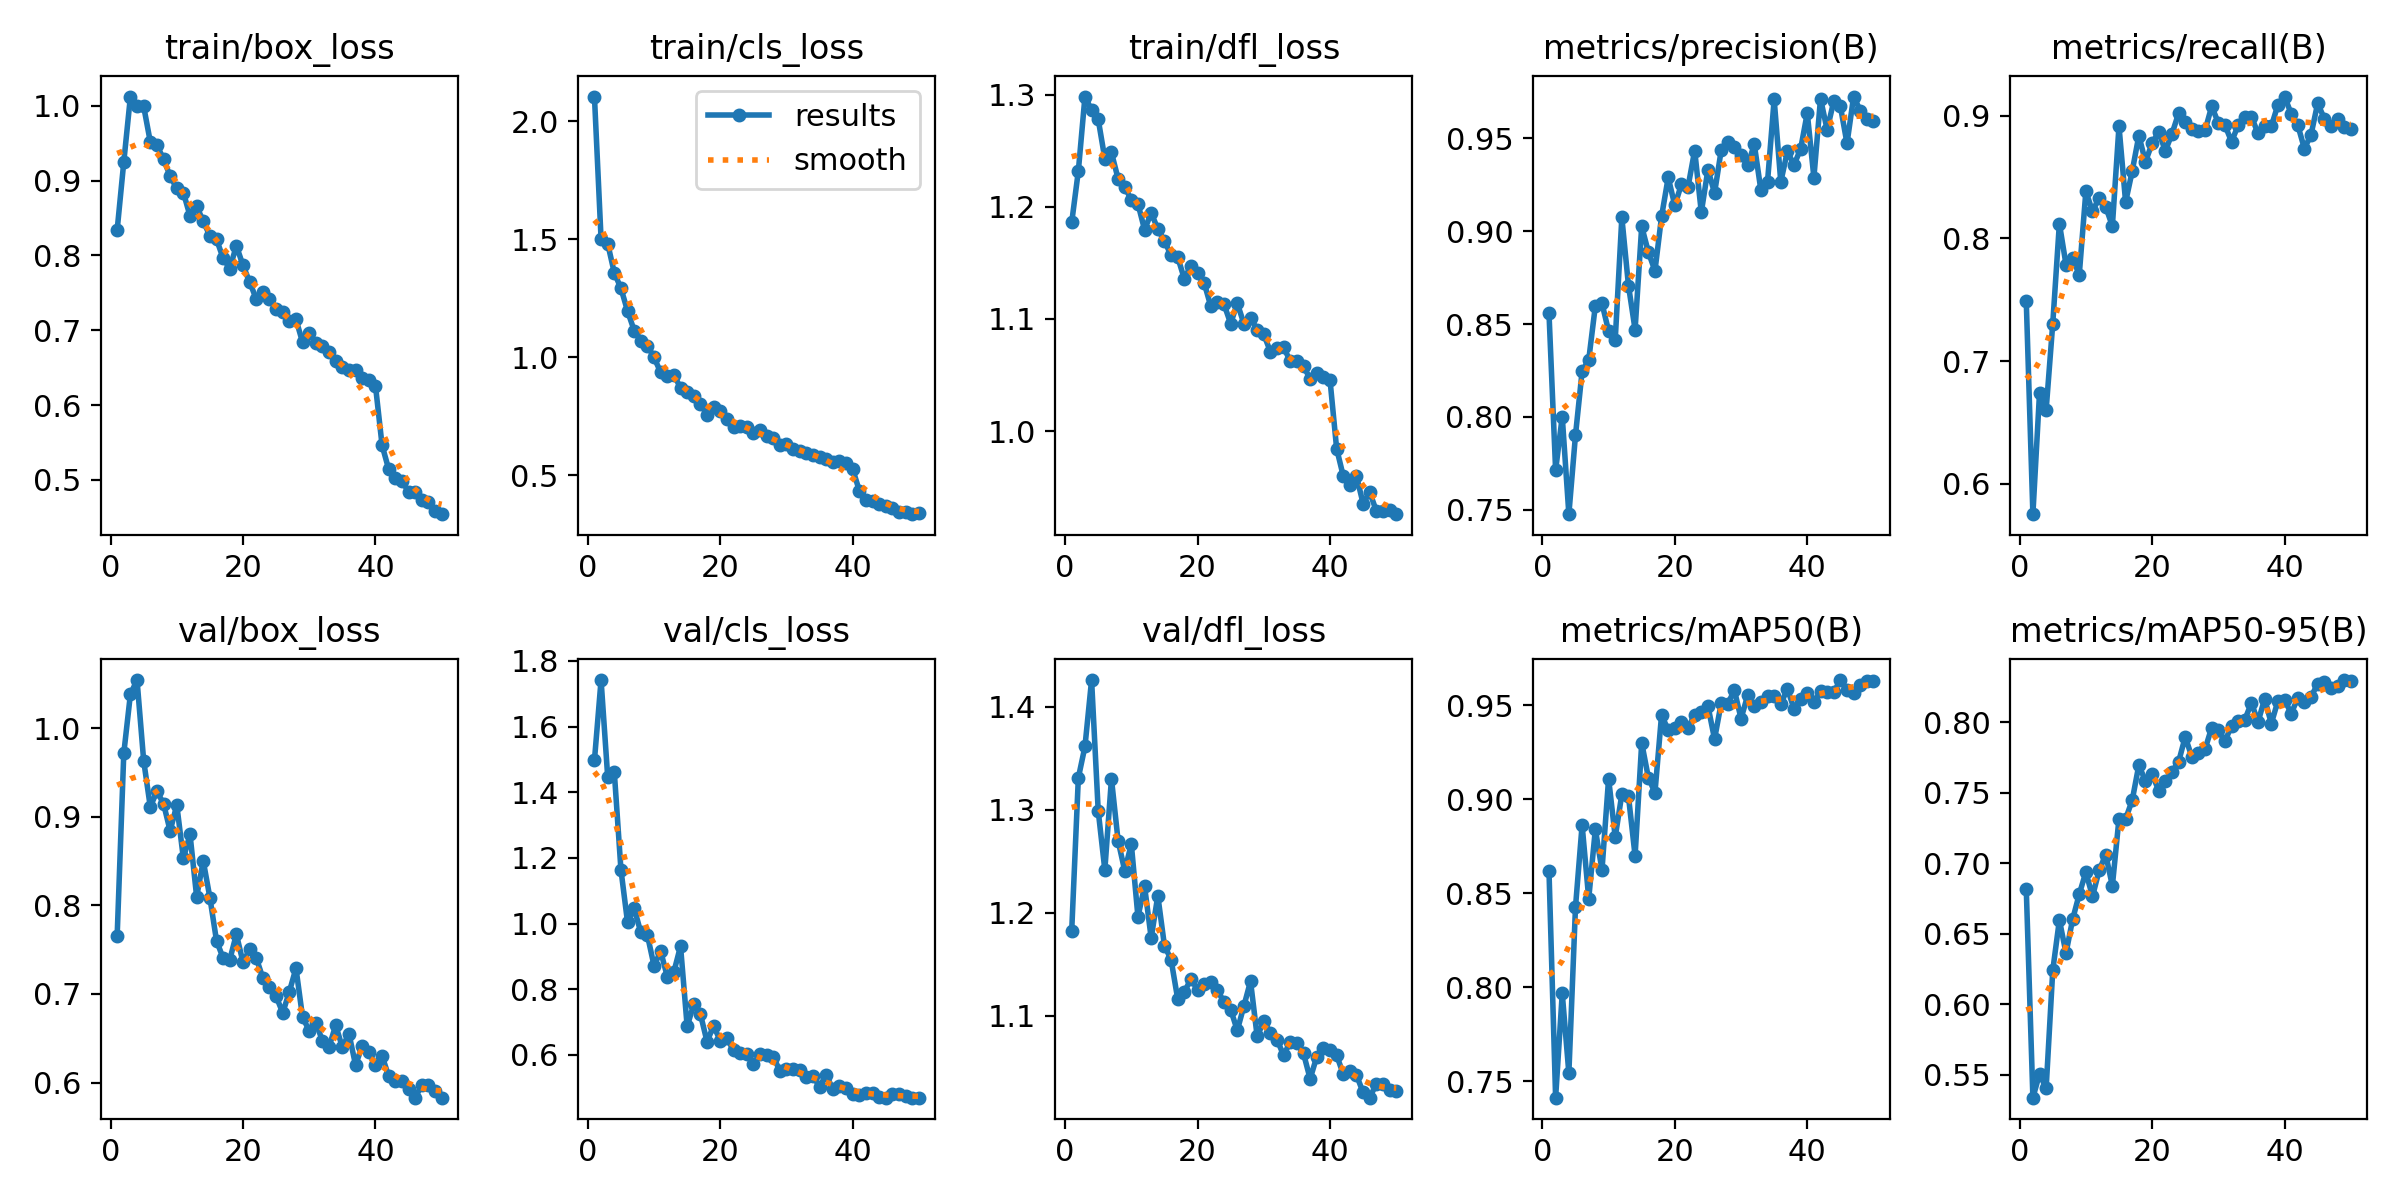


 Confusion matrix 
--------------------------------------------------


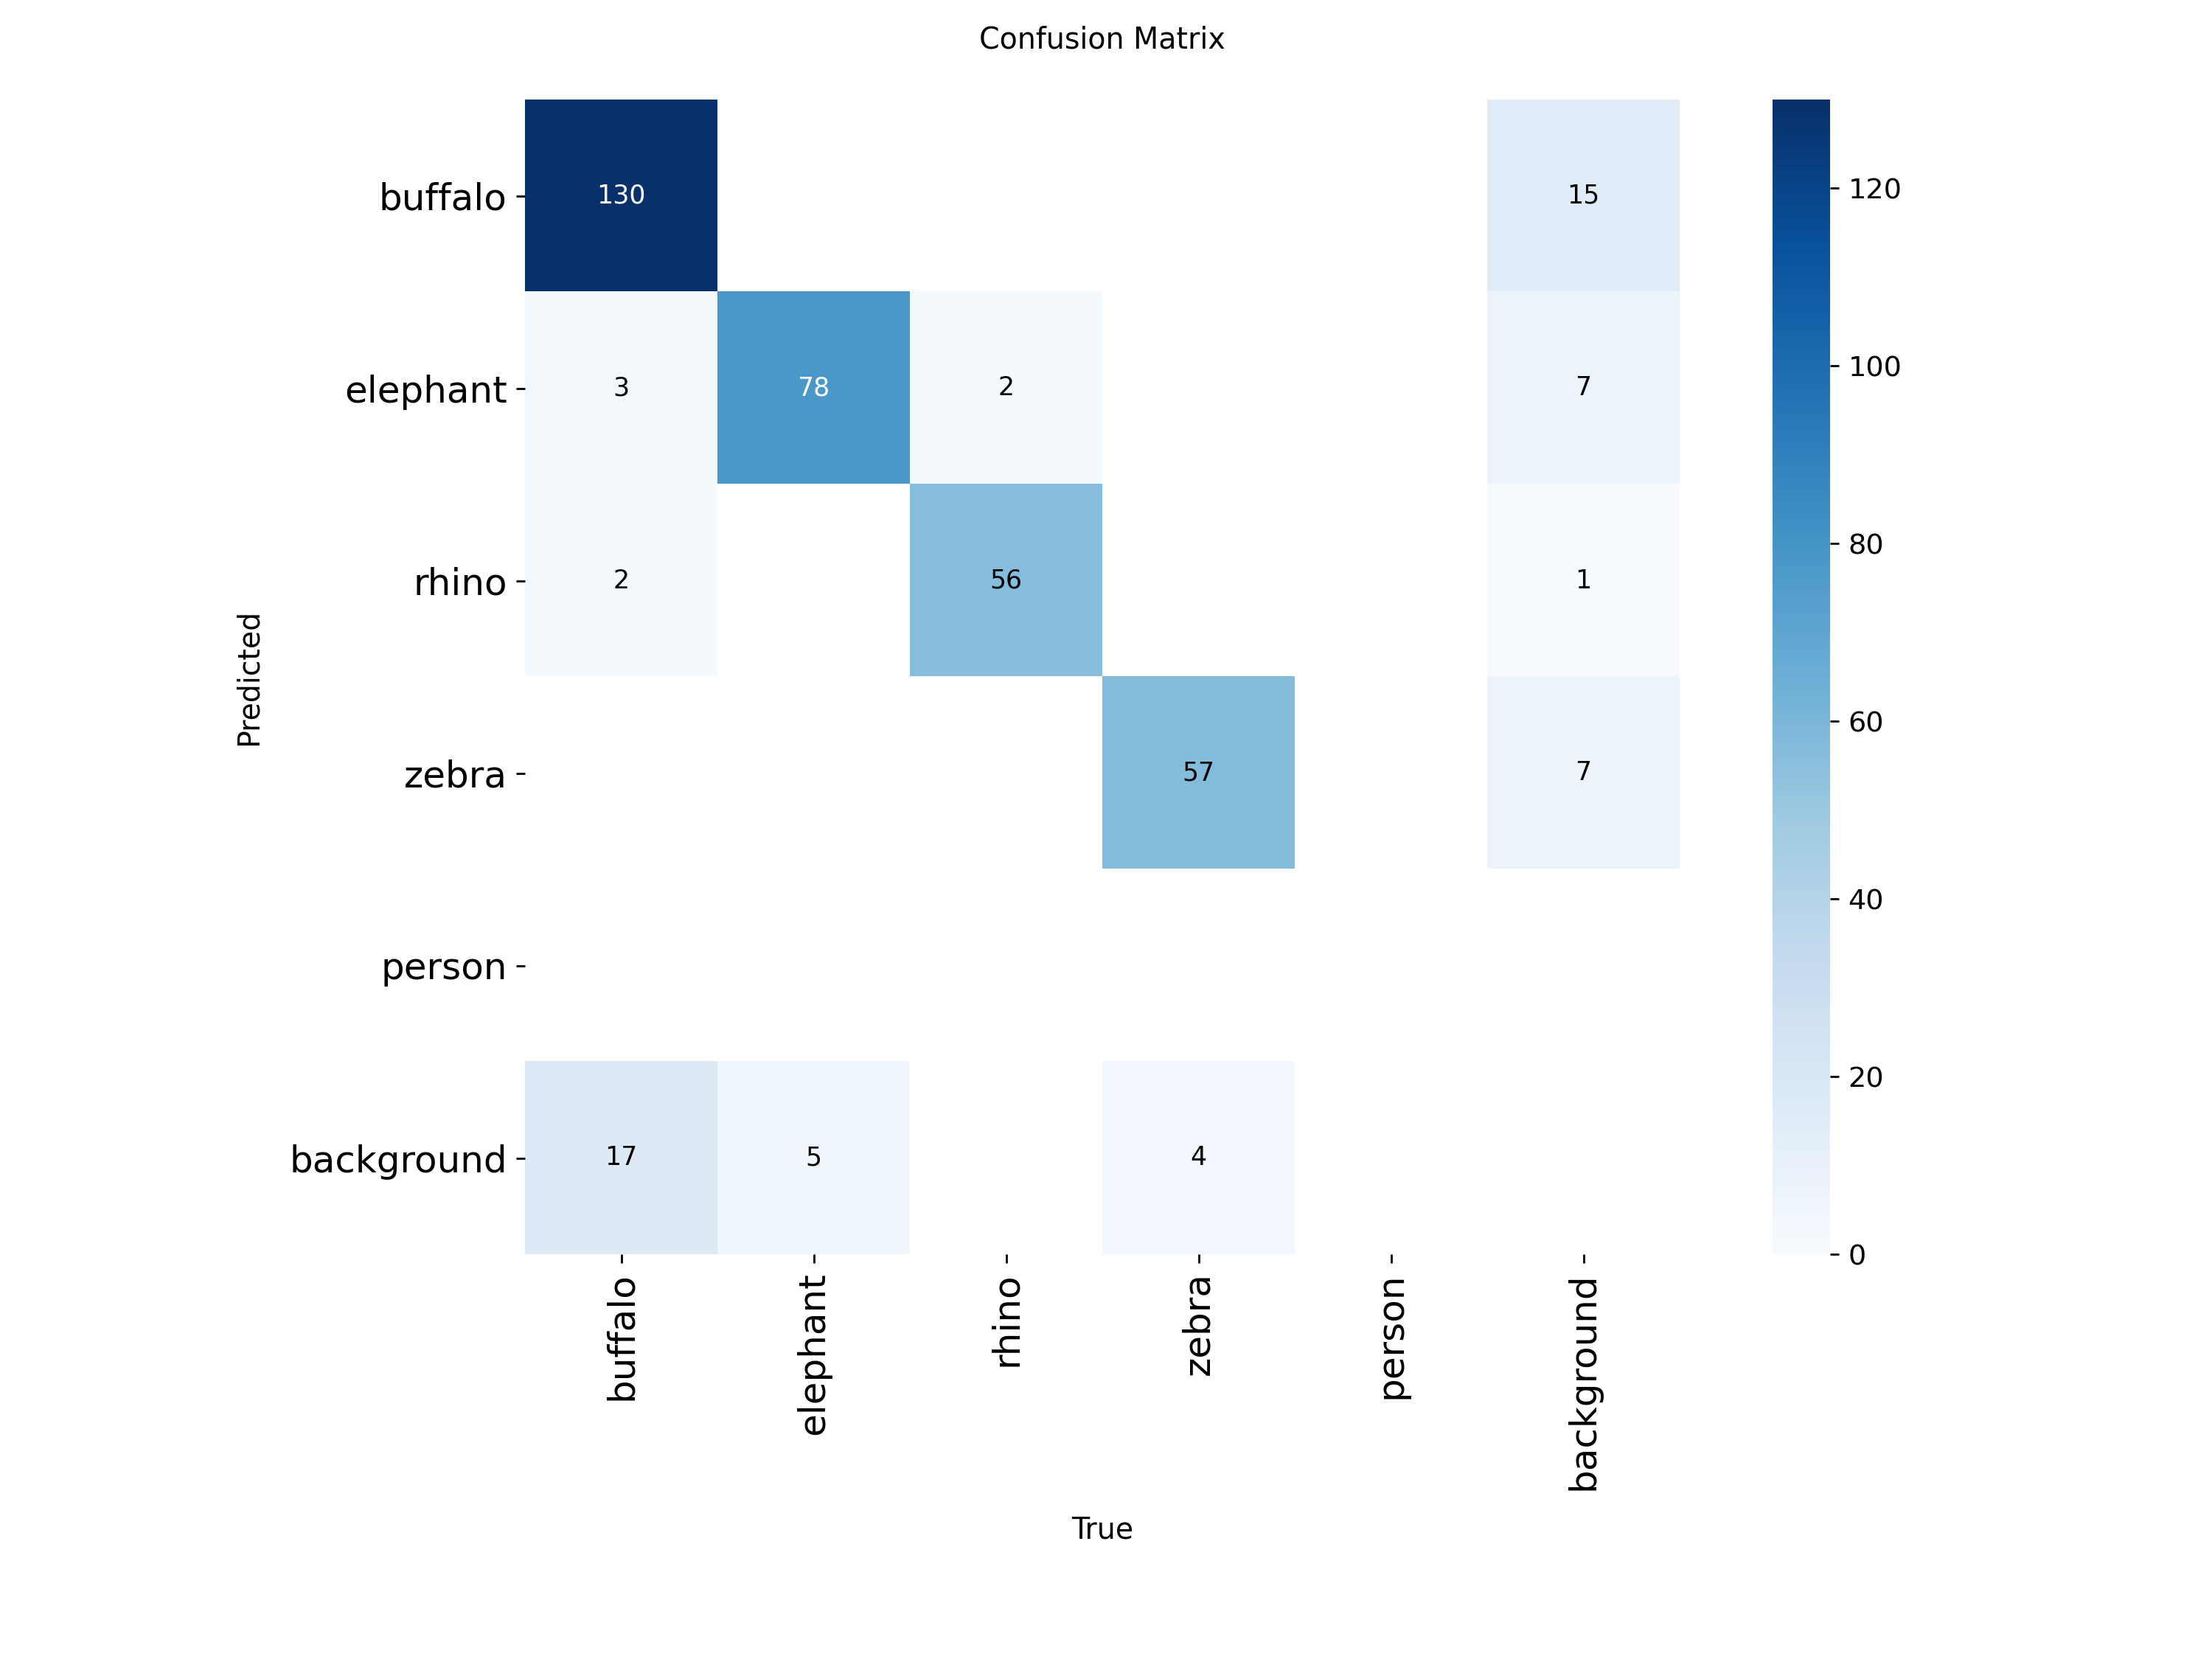


 Exemples de predictions sur le validation set
--------------------------------------------------


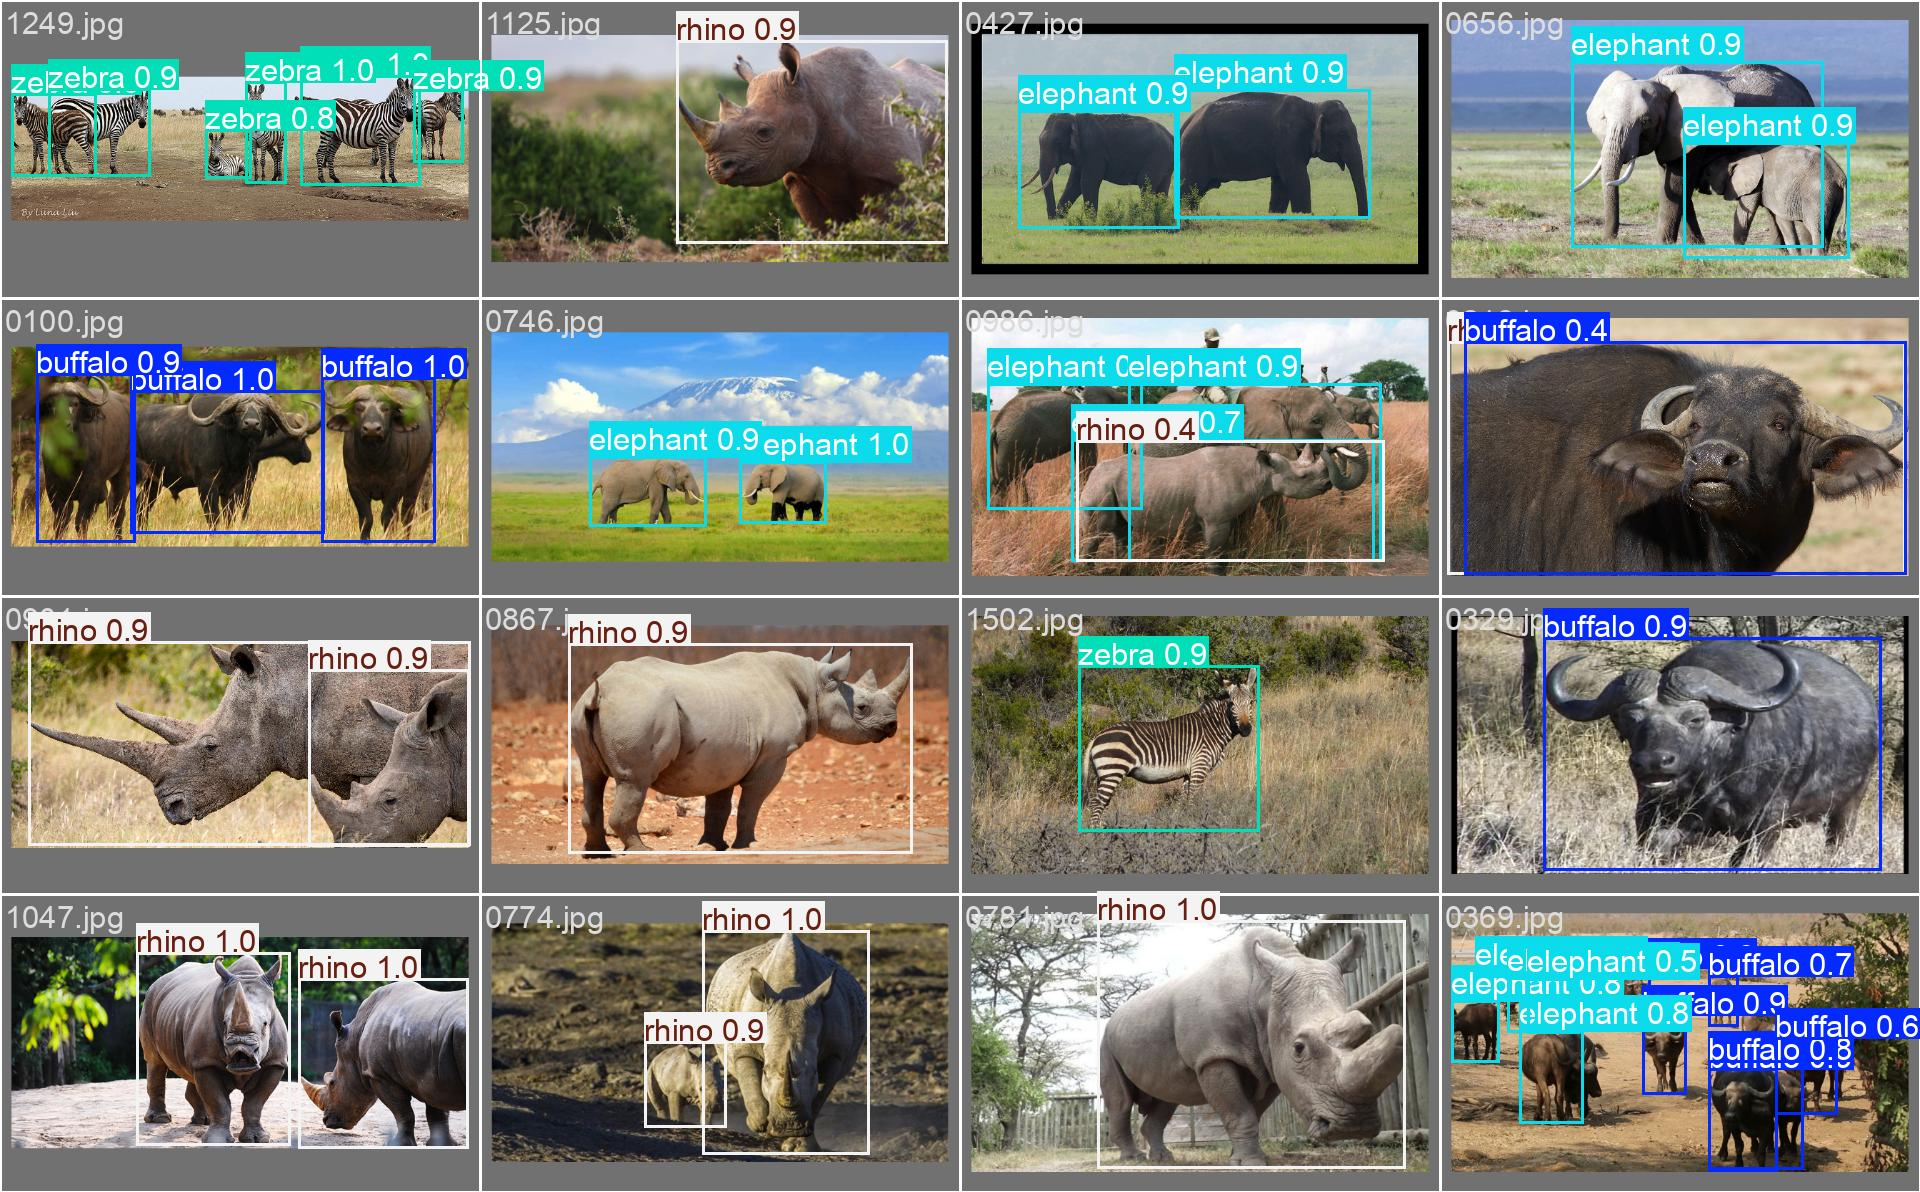

In [31]:
from IPython.display import Image, display

results_dir = Path('runs/detect/wildlife_conflict')

# Courbes d'entrainement
results_png = results_dir / 'results.png'
if results_png.exists():
    print("\n Courbes d'entrainement")
    print("-" * 50)
    display(Image(filename=str(results_png)))

# Matrice de confusion
confusion = results_dir / 'confusion_matrix.png'
if confusion.exists():
    print("\n Confusion matrix ")
    print("-" * 50)
    display(Image(filename=str(confusion)))

# Exemples de predictions
val_batch = results_dir / 'val_batch0_pred.jpg'
if val_batch.exists():
    print("\n Exemples de predictions sur le validation set")
    print("-" * 50)
    display(Image(filename=str(val_batch)))

## Section 10 : Sauvegarde du modèle sur Google Drive

**Objectif** : Sauvegarder le meilleur modèle sur Google Drive pour le réutiliser

**Emplacement** : `MyDrive/ProjetGreenAI/models/wildlife_best.pt`

In [ ]:
import shutil

# Save on drive
best_model_path = 'runs/detect/wildlife_conflict/weights/best.pt'
save_dir = '/content/drive/MyDrive/ProjetGreenAI/models/'

os.makedirs(save_dir, exist_ok=True)
shutil.copy(best_model_path, os.path.join(save_dir, 'wildlife_best.pt'))

print("✅ Modele sauvegarde sur Google Drive")
print(f"Emplacement : {save_dir}wildlife_best.pt")
print("\nVous pouvez maintenant fermer ce notebook")
print("Le modele est pret a etre utilise !")

---
## 📋 Résumé et prochaines étapes

### Ce qui a été fait
✅ Environnement vérifié  
✅ Dataset chargé et vérifié  
✅ Modèle YOLO entraîné pendant 50 époques  
✅ Résultats générés et visualisés  
✅ Modèle sauvegardé sur Google Drive  

### Fichiers générés
- **Modèle entraîné** : `MyDrive/ProjetGreenAI/models/wildlife_best.pt`
- **Résultats** : `runs/detect/wildlife_conflict/`
- **Graphiques** : Dans le dossier results

### Prochaines étapes
1. Tester le modèle sur les 40 images réelles
2. Créer les cartes de densité spatiale
3. Identifier les zones de conflit
4. Préparer la présentation

### Ressources
- Documentation YOLO : https://docs.ultralytics.com
- Repository GitHub : https://github.com/luna-eng-data/wildlife-conflict-detection

---

In [18]:
!pwd
!ls -a

/content/wildlife-conflict-detection
.   02_train_model.ipynb  .git	      LICENSE	 requirements.txt
..  data		  .gitignore  README.md
